In [104]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Machine Learning models
from sklearn.linear_model import LogisticRegression

# Model evaluation
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
from sklearn.metrics import classification_report, roc_curve, auc

# Model selection and feature selection
from sklearn.model_selection import cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, f_classif


In [105]:
x_train_scaled = pd.read_csv("data/x_train_scaled.csv").sort_values(by="video_id", ascending=True)
x_test_scaled = pd.read_csv("data/x_test_scaled.csv").sort_values(by="video_id", ascending=True)

x_train_unscaled = pd.read_csv("data/x_train_unscaled.csv").sort_values(by="video_id", ascending=True)
x_test_unscaled = pd.read_csv("data/x_test_unscaled.csv").sort_values(by="video_id", ascending=True)

y_train = pd.read_csv("data/train_y.csv").sort_values(by="video_id", ascending=True)
y_test = pd.read_csv("data/test_y.csv").sort_values(by="video_id", ascending=True)



CONVERTING CONTINUOUS Y TO BINARY LABELS

📊 Label Conversion Summary:
   Threshold: 0.8
   Label column: label

📊 Training Set Distribution:
   Class 0 (Low, < 0.8): 51 samples (36.4%)
   Class 1 (High, >= 0.8): 89 samples (63.6%)

📊 Test Set Distribution:
   Class 0 (Low, < 0.8): 21 samples (50.0%)
   Class 1 (High, >= 0.8): 21 samples (50.0%)


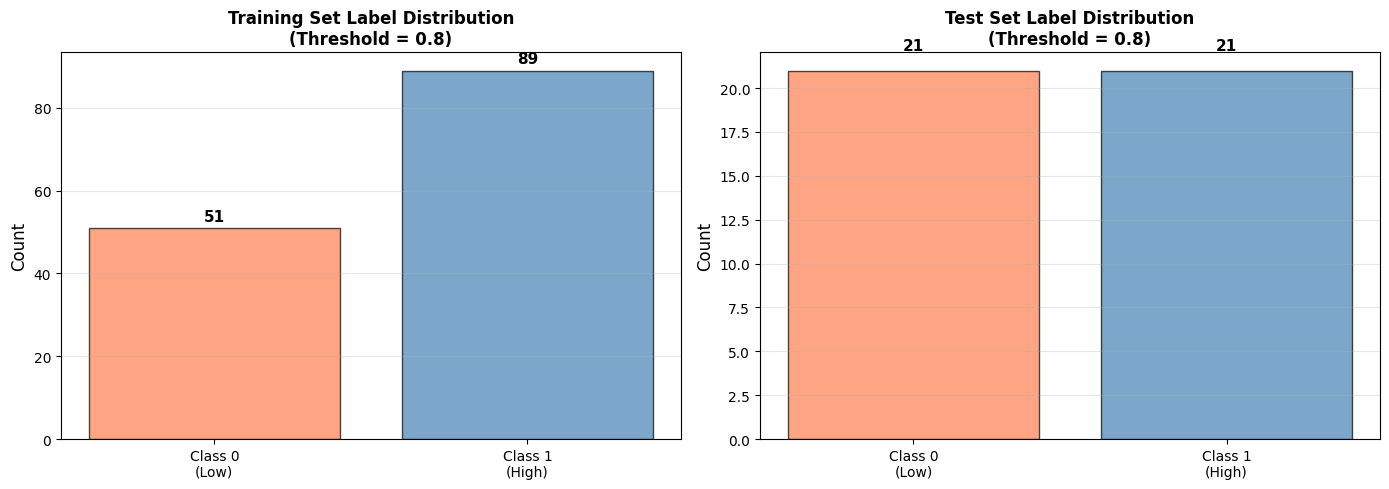


✅ Binary labels created successfully!


In [106]:
# ============================================================================
# CONVERT CONTINUOUS Y TO BINARY LABELS
# ============================================================================
# Convert continuous understandability score to binary classification
# Threshold: >= 0.8 = 1 (High understandability), < 0.8 = 0 (Low understandability)
# ============================================================================

print("=" * 80)
print("CONVERTING CONTINUOUS Y TO BINARY LABELS")
print("=" * 80)

threshold = 0.8

def convert_to_label(y, threshold=0.8):
    """Convert continuous value to binary label"""
    return 1 if y >= threshold else 0

# Get label column name
label_col = y_train.columns[1] if 'video_id' in y_train.columns else y_train.columns[0]

# Convert to binary labels
y_train_binary = y_train[label_col].apply(lambda x: convert_to_label(x, threshold))
y_test_binary = y_test[label_col].apply(lambda x: convert_to_label(x, threshold))

print(f"\n📊 Label Conversion Summary:")
print(f"   Threshold: {threshold}")
print(f"   Label column: {label_col}")

print(f"\n📊 Training Set Distribution:")
train_dist = y_train_binary.value_counts().sort_index()
print(f"   Class 0 (Low, < {threshold}): {train_dist.get(0, 0)} samples ({train_dist.get(0, 0)/len(y_train_binary)*100:.1f}%)")
print(f"   Class 1 (High, >= {threshold}): {train_dist.get(1, 0)} samples ({train_dist.get(1, 0)/len(y_train_binary)*100:.1f}%)")

print(f"\n📊 Test Set Distribution:")
test_dist = y_test_binary.value_counts().sort_index()
print(f"   Class 0 (Low, < {threshold}): {test_dist.get(0, 0)} samples ({test_dist.get(0, 0)/len(y_test_binary)*100:.1f}%)")
print(f"   Class 1 (High, >= {threshold}): {test_dist.get(1, 0)} samples ({test_dist.get(1, 0)/len(y_test_binary)*100:.1f}%)")

# Visualize distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Training set
axes[0].bar(['Class 0\n(Low)', 'Class 1\n(High)'], 
            [train_dist.get(0, 0), train_dist.get(1, 0)],
            color=['coral', 'steelblue'], alpha=0.7, edgecolor='black')
axes[0].set_ylabel('Count', fontsize=12)
axes[0].set_title(f'Training Set Label Distribution\n(Threshold = {threshold})', fontsize=12, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)
for i, v in enumerate([train_dist.get(0, 0), train_dist.get(1, 0)]):
    axes[0].text(i, v + 1, str(v), ha='center', va='bottom', fontsize=11, fontweight='bold')

# Test set
axes[1].bar(['Class 0\n(Low)', 'Class 1\n(High)'], 
            [test_dist.get(0, 0), test_dist.get(1, 0)],
            color=['coral', 'steelblue'], alpha=0.7, edgecolor='black')
axes[1].set_ylabel('Count', fontsize=12)
axes[1].set_title(f'Test Set Label Distribution\n(Threshold = {threshold})', fontsize=12, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)
for i, v in enumerate([test_dist.get(0, 0), test_dist.get(1, 0)]):
    axes[1].text(i, v + 1, str(v), ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n✅ Binary labels created successfully!")
print("=" * 80)

In [107]:
# ============================================================================
# DATA PREPARATION
# ============================================================================
# Align X and y data, prepare features for model training
# ============================================================================

print("=" * 80)
print("DATA PREPARATION")
print("=" * 80)

# Step 1: Align data by video_id
print("\n📊 Step 1: Aligning data by video_id...")

# Get video_ids from each dataset
train_video_ids_x = set(x_train_scaled['video_id'].unique())
test_video_ids_x = set(x_test_scaled['video_id'].unique())
train_video_ids_y = set(y_train['video_id'].unique())
test_video_ids_y = set(y_test['video_id'].unique())

# Find common video_ids
train_common = sorted(list(train_video_ids_x & train_video_ids_y))
test_common = sorted(list(test_video_ids_x & test_video_ids_y))

print(f"   Train: {len(train_common)} common video_ids")
print(f"   Test: {len(test_common)} common video_ids")

# Filter to only common video_ids
x_train_aligned = x_train_scaled[x_train_scaled['video_id'].isin(train_common)].sort_values('video_id').reset_index(drop=True)
x_test_aligned = x_test_scaled[x_test_scaled['video_id'].isin(test_common)].sort_values('video_id').reset_index(drop=True)
y_train_aligned = y_train[y_train['video_id'].isin(train_common)].sort_values('video_id').reset_index(drop=True)
y_test_aligned = y_test[y_test['video_id'].isin(test_common)].sort_values('video_id').reset_index(drop=True)

# Step 2: Prepare features and labels
print("\n📊 Step 2: Preparing features and labels...")

# Remove video_id from features
X_train = x_train_aligned.drop(columns=['video_id']).values
X_test = x_test_aligned.drop(columns=['video_id']).values

# Get binary labels (aligned)
label_col = y_train.columns[1] if 'video_id' in y_train.columns else y_train.columns[0]
y_train_binary_df = pd.DataFrame({
    'video_id': y_train['video_id'].values,
    'label': y_train_binary.values
})
y_test_binary_df = pd.DataFrame({
    'video_id': y_test['video_id'].values,
    'label': y_test_binary.values
})

y_train_binary_aligned = y_train_binary_df[y_train_binary_df['video_id'].isin(train_common)].sort_values('video_id')['label'].values
y_test_binary_aligned = y_test_binary_df[y_test_binary_df['video_id'].isin(test_common)].sort_values('video_id')['label'].values

# Verify alignment
print(f"\n✅ Verification:")
print(f"   X_train shape: {X_train.shape} (samples: {X_train.shape[0]}, features: {X_train.shape[1]})")
print(f"   y_train shape: {y_train_binary_aligned.shape} (samples: {len(y_train_binary_aligned)})")
print(f"   X_test shape: {X_test.shape} (samples: {X_test.shape[0]}, features: {X_test.shape[1]})")
print(f"   y_test shape: {y_test_binary_aligned.shape} (samples: {len(y_test_binary_aligned)})")

if X_train.shape[0] != len(y_train_binary_aligned):
    raise ValueError(f"❌ MISMATCH: X_train has {X_train.shape[0]} samples but y_train has {len(y_train_binary_aligned)} samples!")
if X_test.shape[0] != len(y_test_binary_aligned):
    raise ValueError(f"❌ MISMATCH: X_test has {X_test.shape[0]} samples but y_test has {len(y_test_binary_aligned)} samples!")

# Get feature names for later use
feature_names = x_train_aligned.drop(columns=['video_id']).columns.tolist()

print(f"\n✅ Data prepared successfully!")
print(f"   Features: {len(feature_names)}")
print(f"   Training samples: {X_train.shape[0]}")
print(f"   Test samples: {X_test.shape[0]}")
print("=" * 80)

DATA PREPARATION

📊 Step 1: Aligning data by video_id...
   Train: 140 common video_ids
   Test: 42 common video_ids

📊 Step 2: Preparing features and labels...

✅ Verification:
   X_train shape: (140, 31) (samples: 140, features: 31)
   y_train shape: (140,) (samples: 140)
   X_test shape: (42, 31) (samples: 42, features: 31)
   y_test shape: (42,) (samples: 42)

✅ Data prepared successfully!
   Features: 31
   Training samples: 140
   Test samples: 42


In [108]:
# ============================================================================
# BASELINE MODEL: Simple Logistic Regression (No Feature Selection)
# ============================================================================
# Evaluate baseline performance before feature selection and hyperparameter tuning
# ============================================================================

print("=" * 80)
print("BASELINE MODEL EVALUATION")
print("=" * 80)

# Define baseline model
baseline_model = LogisticRegression(solver='liblinear', random_state=42, max_iter=1000)

# Perform stratified cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(baseline_model, X_train, y_train_binary_aligned, cv=cv, scoring='accuracy')

print(f"\n📊 Baseline Logistic Regression (No Feature Selection, Default Parameters):")
print(f"   Cross-validation scores: {cv_scores}")
print(f"   Mean CV accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")

# Train on full training set for baseline comparison
baseline_model.fit(X_train, y_train_binary_aligned)
baseline_train_acc = accuracy_score(y_train_binary_aligned, baseline_model.predict(X_train))
baseline_test_acc = accuracy_score(y_test_binary_aligned, baseline_model.predict(X_test))

print(f"\n📊 Baseline Performance on Full Dataset:")
print(f"   Train Accuracy: {baseline_train_acc:.4f}")
print(f"   Test Accuracy: {baseline_test_acc:.4f}")

print("\n" + "=" * 80)


BASELINE MODEL EVALUATION

📊 Baseline Logistic Regression (No Feature Selection, Default Parameters):
   Cross-validation scores: [0.5        0.67857143 0.67857143 0.57142857 0.67857143]
   Mean CV accuracy: 0.6214 (+/- 0.1471)

📊 Baseline Performance on Full Dataset:
   Train Accuracy: 0.7143
   Test Accuracy: 0.4762



In [109]:
# ============================================================================
# LOGISTIC REGRESSION: Feature Selection + Hyperparameter Tuning
# ============================================================================
# Use Pipeline with feature selection and GridSearchCV
# ============================================================================

print("=" * 80)
print("LOGISTIC REGRESSION: Feature Selection + Hyperparameter Tuning")
print("=" * 80)

# Create pipeline with feature selection and Logistic Regression
pipeline = Pipeline([
    ('feature_selection', SelectKBest(f_classif)),
    ('classification', LogisticRegression(solver='liblinear', random_state=42, max_iter=1000))
])

# Parameter grid for optimization
param_grid = {
    'feature_selection__k': [5, 10, 15, 20, 25, 30, 35, 40, 50],
    'classification__C': [0.0001, 0.001, 0.01, 0.1, 0.5, 1, 2, 5, 10, 50, 100, 500],
    'classification__penalty': ['l1', 'l2'],
    'classification__class_weight': [None, 'balanced'],
    'classification__fit_intercept': [True, False]
}

# Stratified K-Fold for cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Calculate total parameter combinations
total_combinations = (len(param_grid['feature_selection__k']) * 
                     len(param_grid['classification__C']) * 
                     len(param_grid['classification__penalty']) *
                     len(param_grid['classification__class_weight']) *
                     len(param_grid['classification__fit_intercept']))

print(f"\n🚀 Starting GridSearchCV optimization...")
print(f"   Feature selection k values: {len(param_grid['feature_selection__k'])} options")
print(f"   Regularization C values: {len(param_grid['classification__C'])} options")
print(f"   Penalty types: {len(param_grid['classification__penalty'])} options")
print(f"   Class weights: {len(param_grid['classification__class_weight'])} options")
print(f"   Fit intercept: {len(param_grid['classification__fit_intercept'])} options")
print(f"   Total parameter combinations: {total_combinations}")
print(f"   With 5-fold CV: {total_combinations * 5} model fits")
print("=" * 80)

# Grid search
grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1,  # Use all available CPUs
    verbose=1
)

# Fit grid search
grid_search.fit(X_train, y_train_binary_aligned)

# Get best model
best_model = grid_search.best_estimator_

print("\n" + "=" * 80)
print("OPTIMIZATION COMPLETE!")
print("=" * 80)

# Display best parameters and score
print(f"\n🏆 Best Parameters:")
for param, value in grid_search.best_params_.items():
    print(f"   {param}: {value}")

print(f"\n📊 Best CV Score: {grid_search.best_score_:.4f}")

# Get selected features
selected_features_mask = best_model.named_steps['feature_selection'].get_support()
selected_features = [feature_names[i] for i in range(len(feature_names)) if selected_features_mask[i]]
n_selected_features = len(selected_features)

print(f"\n📋 Selected Features: {n_selected_features} out of {len(feature_names)}")
print("=" * 80)

# Make predictions
y_train_pred = best_model.predict(X_train)
y_test_pred = best_model.predict(X_test)

# Get probabilities for AUC
try:
    y_train_proba = best_model.predict_proba(X_train)[:, 1]
    y_test_proba = best_model.predict_proba(X_test)[:, 1]
    train_auc = roc_auc_score(y_train_binary_aligned, y_train_proba)
    test_auc = roc_auc_score(y_test_binary_aligned, y_test_proba)
except:
    train_auc = None
    test_auc = None

# Calculate all metrics
train_acc = accuracy_score(y_train_binary_aligned, y_train_pred)
test_acc = accuracy_score(y_test_binary_aligned, y_test_pred)
train_precision = precision_score(y_train_binary_aligned, y_train_pred, average='weighted', zero_division=0)
test_precision = precision_score(y_test_binary_aligned, y_test_pred, average='weighted', zero_division=0)
train_recall = recall_score(y_train_binary_aligned, y_train_pred, average='weighted', zero_division=0)
test_recall = recall_score(y_test_binary_aligned, y_test_pred, average='weighted', zero_division=0)
train_f1 = f1_score(y_train_binary_aligned, y_train_pred, average='weighted', zero_division=0)
test_f1 = f1_score(y_test_binary_aligned, y_test_pred, average='weighted', zero_division=0)

# Display performance metrics
print("\n" + "=" * 80)
print("MODEL PERFORMANCE")
print("=" * 80)

print(f"\n📊 Training Set Performance:")
print(f"   Accuracy:  {train_acc:.4f}")
print(f"   Precision: {train_precision:.4f}")
print(f"   Recall:    {train_recall:.4f}")
print(f"   F1 Score:  {train_f1:.4f}")
if train_auc is not None:
    print(f"   AUC-ROC:   {train_auc:.4f}")

print(f"\n📊 Test Set Performance:")
print(f"   Accuracy:  {test_acc:.4f}")
print(f"   Precision: {test_precision:.4f}")
print(f"   Recall:    {test_recall:.4f}")
print(f"   F1 Score:  {test_f1:.4f}")
if test_auc is not None:
    print(f"   AUC-ROC:   {test_auc:.4f}")

print("\n" + "=" * 80)


LOGISTIC REGRESSION: Feature Selection + Hyperparameter Tuning

🚀 Starting GridSearchCV optimization...
   Feature selection k values: 9 options
   Regularization C values: 12 options
   Penalty types: 2 options
   Class weights: 2 options
   Fit intercept: 2 options
   Total parameter combinations: 864
   With 5-fold CV: 4320 model fits
Fitting 5 folds for each of 864 candidates, totalling 4320 fits

OPTIMIZATION COMPLETE!

🏆 Best Parameters:
   classification__C: 50
   classification__class_weight: None
   classification__fit_intercept: True
   classification__penalty: l2
   feature_selection__k: 10

📊 Best CV Score: 0.6429

📋 Selected Features: 10 out of 31

MODEL PERFORMANCE

📊 Training Set Performance:
   Accuracy:  0.6714
   Precision: 0.6621
   Recall:    0.6714
   F1 Score:  0.6645
   AUC-ROC:   0.7306

📊 Test Set Performance:
   Accuracy:  0.5000
   Precision: 0.5000
   Recall:    0.5000
   F1 Score:  0.4470
   AUC-ROC:   0.5986



VISUALIZATION AND DETAILED ANALYSIS

📊 Classification Report (Test Set):
              precision    recall  f1-score   support

         Low       0.50      0.19      0.28        21
        High       0.50      0.81      0.62        21

    accuracy                           0.50        42
   macro avg       0.50      0.50      0.45        42
weighted avg       0.50      0.50      0.45        42



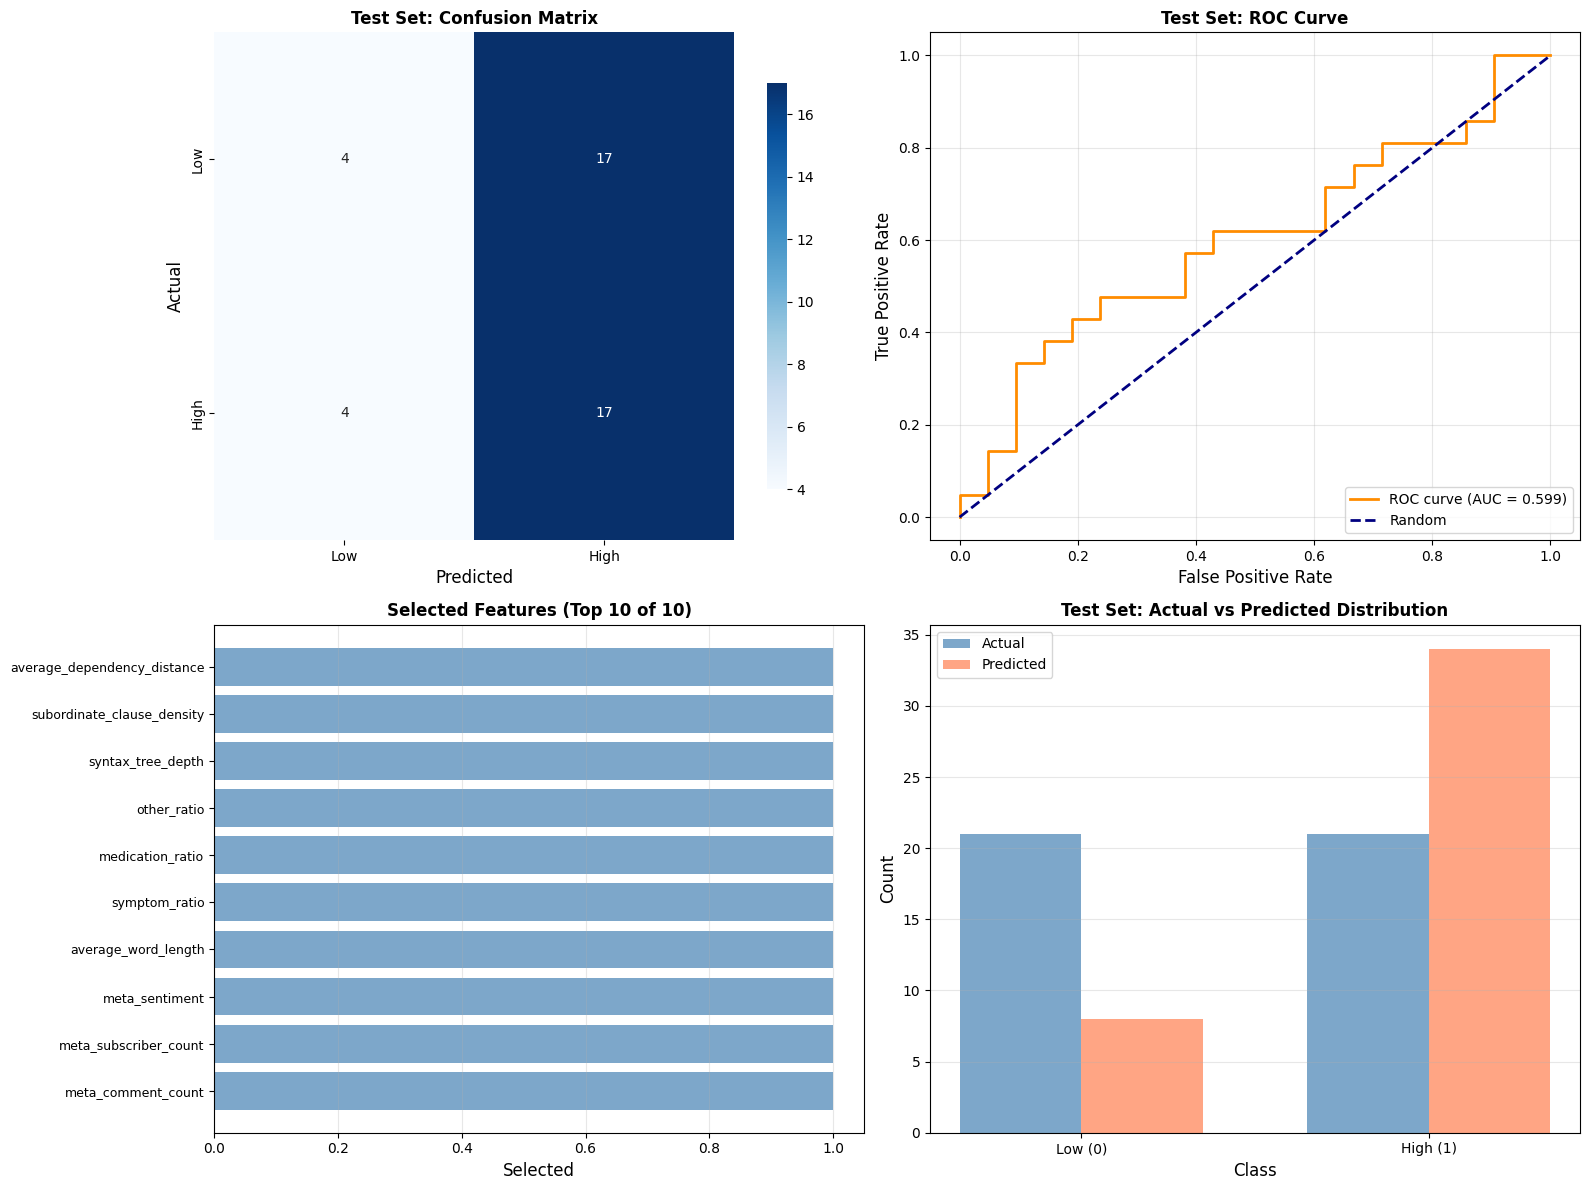


📋 All Selected Features (10):
    1. meta_comment_count
    2. meta_subscriber_count
    3. meta_sentiment
    4. average_word_length
    5. symptom_ratio
    6. medication_ratio
    7. other_ratio
    8. syntax_tree_depth
    9. subordinate_clause_density
   10. average_dependency_distance



In [110]:
# ============================================================================
# VISUALIZATION AND DETAILED ANALYSIS
# ============================================================================

print("=" * 80)
print("VISUALIZATION AND DETAILED ANALYSIS")
print("=" * 80)

# Confusion Matrix
cm_test = confusion_matrix(y_test_binary_aligned, y_test_pred)

# Classification Report
print(f"\n📊 Classification Report (Test Set):")
print("=" * 80)
print(classification_report(y_test_binary_aligned, y_test_pred, target_names=['Low', 'High']))

# Visualizations
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Confusion Matrix
ax1 = axes[0, 0]
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues', ax=ax1, cbar_kws={'shrink': 0.8},
            xticklabels=['Low', 'High'], yticklabels=['Low', 'High'])
ax1.set_xlabel('Predicted', fontsize=12)
ax1.set_ylabel('Actual', fontsize=12)
ax1.set_title('Test Set: Confusion Matrix', fontsize=12, fontweight='bold')

# Plot 2: ROC Curve
ax2 = axes[0, 1]
if y_test_proba is not None:
    fpr, tpr, _ = roc_curve(y_test_binary_aligned, y_test_proba)
    roc_auc = auc(fpr, tpr)
    ax2.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
    ax2.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random')
    ax2.set_xlabel('False Positive Rate', fontsize=12)
    ax2.set_ylabel('True Positive Rate', fontsize=12)
    ax2.set_title('Test Set: ROC Curve', fontsize=12, fontweight='bold')
    ax2.legend(loc="lower right")
    ax2.grid(alpha=0.3)
else:
    ax2.text(0.5, 0.5, 'ROC curve not available', 
            ha='center', va='center', fontsize=12, transform=ax2.transAxes)
    ax2.set_title('ROC Curve (Not Available)', fontsize=12, fontweight='bold')

# Plot 3: Selected Features (Top 15)
ax3 = axes[1, 0]
if len(selected_features) > 0:
    features_to_show = selected_features[:15] if len(selected_features) > 15 else selected_features
    ax3.barh(range(len(features_to_show)), [1] * len(features_to_show), color='steelblue', alpha=0.7)
    ax3.set_yticks(range(len(features_to_show)))
    ax3.set_yticklabels([f[:30] for f in features_to_show], fontsize=9)
    ax3.set_xlabel('Selected', fontsize=12)
    ax3.set_title(f'Selected Features (Top {len(features_to_show)} of {len(selected_features)})', 
                  fontsize=12, fontweight='bold')
    ax3.grid(axis='x', alpha=0.3)
    if len(selected_features) > 15:
        ax3.text(0.5, -0.15, f'... and {len(selected_features) - 15} more features', 
                ha='center', transform=ax3.transAxes, fontsize=9, style='italic')
else:
    ax3.text(0.5, 0.5, 'No features selected', 
            ha='center', va='center', fontsize=12, transform=ax3.transAxes)
    ax3.set_title('Selected Features', fontsize=12, fontweight='bold')

# Plot 4: Prediction Distribution
ax4 = axes[1, 1]
unique_actual, counts_actual = np.unique(y_test_binary_aligned, return_counts=True)
x_pos = np.arange(len(unique_actual))
width = 0.35
ax4.bar(x_pos - width/2, counts_actual, width, label='Actual', color='steelblue', alpha=0.7)
pred_counts = np.zeros(len(unique_actual))
for i, cls in enumerate(unique_actual):
    pred_counts[i] = np.sum(y_test_pred == cls)
ax4.bar(x_pos + width/2, pred_counts, width, label='Predicted', color='coral', alpha=0.7)
ax4.set_xticks(x_pos)
ax4.set_xticklabels(['Low (0)', 'High (1)'], fontsize=10)
ax4.set_ylabel('Count', fontsize=12)
ax4.set_xlabel('Class', fontsize=12)
ax4.set_title('Test Set: Actual vs Predicted Distribution', fontsize=12, fontweight='bold')
ax4.legend()
ax4.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Display all selected features
print(f"\n📋 All Selected Features ({len(selected_features)}):")
print("=" * 80)
for i, feat in enumerate(selected_features, 1):
    print(f"   {i:2d}. {feat}")

print("\n" + "=" * 80)


## Decision Tree